From Last Time:
    
Recall $(A^TA+\lambda I_n)^{-1}A^T$ is well-defined for any positive lambda. Let's take the limit as $\lambda\to 0^+$.

$\lim_{\lambda\to0^+}(A^TA+\lambda I_n)^{-1}A^T=A^+$

(This will be on HW 10)

**Today: Constrained Least Squares Problems**

Data: $A\in \mathbb{R}^{m\times n}$, $b\in \mathbb{R}^m$, $C\in \mathbb{R}^{p\times n}, d\in \mathbb{R}^p$.

Goal: $\min \|b-Ax\|_2^2$ subject to $Cx=d$

Solution Via Lagrange Multipliers:

We'll have $p$ many Lagrange multipliers $\lambda_1,\ldots,\lambda_p$, one for each constraint. Let $\lambda=[\lambda_1,\ldots,\lambda_p]^T$.

We now define the following Lagrangian function:

$L(x,\lambda) = \min \|b-Ax\|_2^2+\lambda^T(Cx-d)$.

We need to solve $\nabla L = 0$, ie $\nabla L = [\nabla_x L \nabla_\lambda L]^T = [0|0]^T$

See that $\nabla_\lambda L = Cx - d = 0$ and $\nabla_x = 2A^TAx - 2A^Tb+C^T\lambda=0$, which comes from our work on Monday.

Storing in a block matrix (kind of):

$[2A^TA,C^T; C,0][X; Y]=[2A^Tb; d]$

We can then use Python (or whatever) to solve this system.

**Application: spline regression**

Suppose we have data following some curve. Fit to this data the piecewise function $f(x)$ given by the polynomial $p(x)$ for $x\leq a$ and $q(x)$ for $x>a$. We enforce $p(a) = q(a)$ and $p'(a)=q'(a)$.

Example: $p(x)$ and $q(x)$ are both cubic polynomials. Set

$p(x) = \theta_1 + \theta_2x+\theta_3x^2+\theta_4x^3, q(x) = \theta_5 + \theta_6x+\theta_7x^2+\theta_8x^3$.

Suppose $x_1,x_2,\ldots,x_M \leq a$ and $x_{M+1},\ldots,x_m>a$. We'll minimize:

$\sum_{i=1}^M(y_i-(\theta_1 + \theta_2x+\theta_3x^2+\theta_4x^3))^2+\sum_{i=M+1}^m(y_i-(\theta_5 + \theta_6x+\theta_7x^2+\theta_8x^3))^2$ 

Subject to:

$\theta_1-\theta_5+\theta_2a-\theta_6a+\theta_3a^2-\theta_7a^2+\theta_4a^3-\theta_8a^3=0$ and

$\theta_2-\theta_6+2\theta_3a-2\theta_7a+3\theta_4a^2-3\theta_8a^2=0$

Storing as a block matrix:

$A_{11}=[1,x_1,x_1^2,x_1^3;\ldots;1,x_M,x_M^2,x_M^3]$

$A_{12}=0$

$A_{21}=0$

$A_{22}=[1,x_{M+1},x_{M+1}^2,x_{M+1}^3;\ldots;1,x_m,x_m^2,x_m^3]$

$b= [y_1,y_2,\ldots,y_m]^T$

$C = [1,a,a^2,a^3,-1,-a,-a^2,-a^3;0,1,2a,3a^2,-,-1,-2a,-3a^2]$

$d=[0,0]^T$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, block_diag

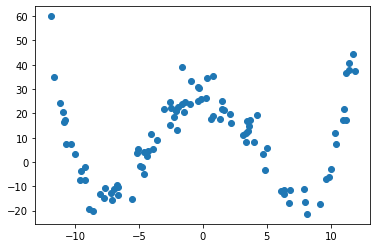

In [2]:
m = 100
# m random points on [-12,12]
x = -12+24*np.random.rand(m)
y = 0.01*(x-10)*(x-5)*(x+5)*(x+10)+5*np.random.randn(m)

plt.scatter(x,y)

In [3]:
deg = 3
a = 0
# you can play with these

In [4]:
x1 = x[x<=a]
m1 = len(x1)
x2 = x[x>a]
m2 = len(x2)

In [5]:
#Matrix A

A1 = np.ones((m1,deg+1))
A2 = np.ones((m2,deg+1))

for i in range(deg+1):
    A1[:,i]=x1**i
    A2[:,i]=x2**i
    
A = block_diag(A1,A2)

In [6]:
# vector b

b = np.concatenate((y[x<=a],y[x>a]))

In [7]:
# matrix C
C = np.zeros((2,2*(deg+1)))
C[0,0:deg+1] = [a**i for i in range(deg+1)]
C[0,deg+1:] = [-a**i for i in range(deg+1)]

C[1,1:deg+1] = [i*a**(i-1) for i in range(1,deg+1)]
C[1,deg+2:] = [-i*a**(i-1) for i in range(1,deg+1)]

d = np.array([0,0])

In [8]:
Matrix = np.block([[2*A.T.dot(A),C.T],[C,np.zeros((2,2))]])
vector = np.concatenate((2*A.T.dot(b),d))
solution = solve(Matrix, vector)

In [9]:
coeffs1 = solution[0:deg+1]
coeffs2 = solution[deg+1:2*(deg+1)]

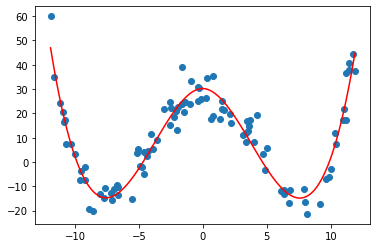

In [10]:
# plot fitted polynomials
m_plot = 100
x1_plot = np.linspace(np.min(x),a,m_plot)
x2_plot = np.linspace(a,np.max(x),m_plot)

A1 = np.ones((m_plot,deg+1))
A2 = np.ones((m_plot,deg+1))
for i in range(deg+1):
    A1[:,i] = x1_plot**i
    A2[:,i] = x2_plot**i

y1_plot = A1.dot(coeffs1)
y2_plot = A2.dot(coeffs2)

plt.scatter(x,y)
plt.plot(x1_plot,y1_plot,color='red')
plt.plot(x2_plot,y2_plot,color='red')